# Estudo do Uso de Contadores Inteligentes

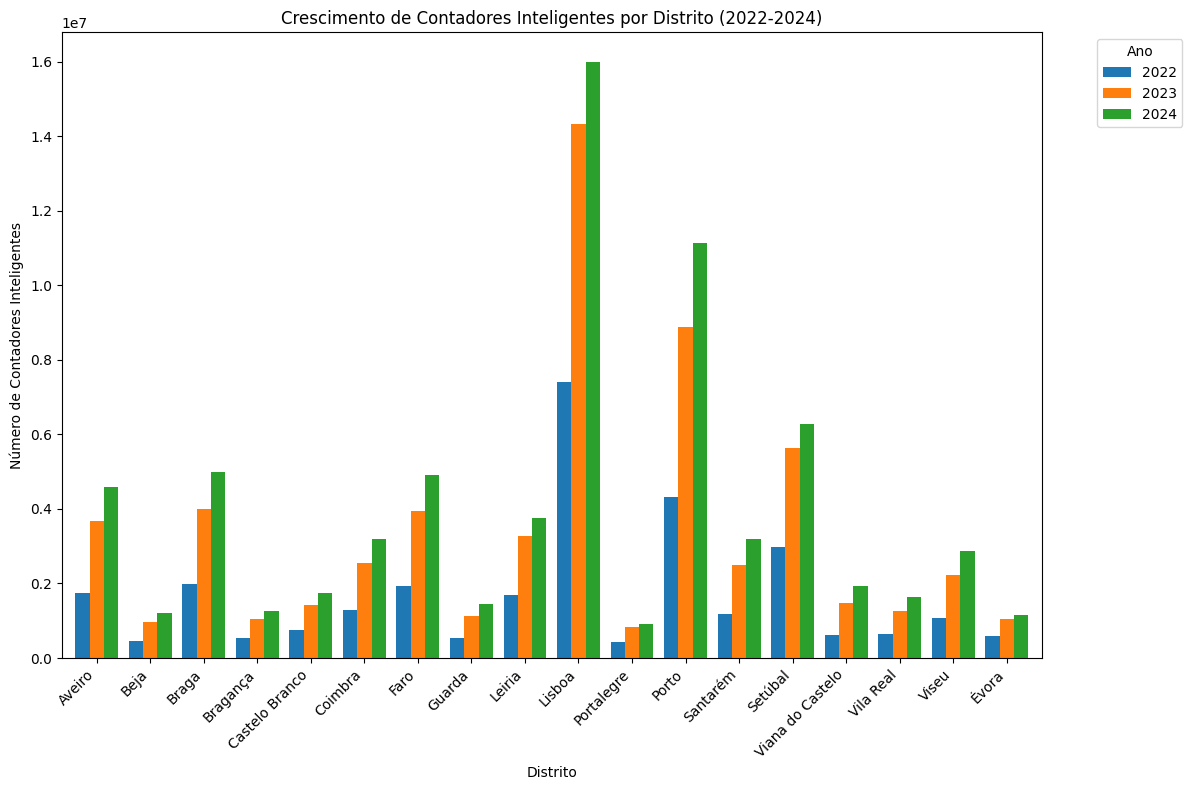

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/contadores.csv', sep=';')

# Filtrar apenas os contadores inteligentes
dados_inteligentes = dados[dados['Inclui contador inteligente'] == 'Sim']

# Filtrar os dados para os anos de 2022 a 2024
dados_inteligentes = dados_inteligentes[dados_inteligentes['Ano'].isin([2022, 2023, 2024])]

# Agrupar por Distrito e Ano, somando o número de CPE's (Número de instalações de contadores inteligentes)
tabela_inteligentes = dados_inteligentes.groupby(['Distrito', 'Ano'])['Número de CPE\'s'].sum().reset_index()

# Pivotar os dados para que os distritos sejam as linhas e os anos sejam as colunas
tabela_inteligentes_pivot = tabela_inteligentes.pivot(index='Distrito', columns='Ano', values='Número de CPE\'s').fillna(0)

# Criar gráfico de barras
tabela_inteligentes_pivot.plot(kind='bar', figsize=(12, 8), width=0.8)

# Adicionar título e rótulos
plt.title('Crescimento de Contadores Inteligentes por Distrito (2022-2024)')
plt.xlabel('Distrito')
plt.ylabel('Número de Contadores Inteligentes')

# Ajustar o eixo X para exibir os distritos corretamente
plt.xticks(rotation=45, ha='right')

# Exibir legenda com os anos
plt.legend(title='Ano', bbox_to_anchor=(1.05, 1), loc='upper left')

# Exibir gráfico
plt.tight_layout()
plt.show()
